# Step 3 — Exploratory Data Analysis

**Project:** Prompt Engineering for Clothing Review Analysis  
**Dataset:** Women's Clothing E-Commerce Reviews (`data/reviews.csv`)  
**Goal:** Understand the structure, quality, and key distributions of the review data before designing prompts.

This notebook documents the raw data we will later summarize, classify, and extract insights from using prompt engineering techniques.

## 0. Setup

Load the CSV from the repository `data/` folder. The path is resolved relative to the Jupyter working directory: `data/reviews.csv` if the kernel was started from the project root, otherwise `../data/reviews.csv` if it was started inside `prompts/`.

The first column is an unnamed row index, so it is read as the DataFrame index. Display options are widened so full review text is visible in sample rows.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 400)
pd.set_option("display.width", 120)

DATA_PATH = (
    Path("data/reviews.csv")
    if Path("data/reviews.csv").exists()
    else Path("..") / "data" / "reviews.csv"
)
df = pd.read_csv(DATA_PATH, index_col=0)

print(f"Loaded: {DATA_PATH.resolve()}")
df.head(3)

Matplotlib is building the font cache; this may take a moment.


Loaded: C:\GamageRecruiters-DataScienceIntern\Month_02\prompt-engineering-task\data\reviews.csv


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite.",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,"I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my usual size) but i found this to be outrageously small. so small in fact that i could not zip it up! i reordered it in petite medium, which was just ok. overall, the top half was comfortable and fit nicely, but the bottom half had a very tight under layer and several somewhat cheap...",3,0,0,General,Dresses,Dresses


## 1. Dataset shape

**Finding:** The file contains **23,486 reviews** and **10 feature columns** after treating the leading index column as the row index.

This is a medium-sized text dataset: large enough for reliable frequency analysis, but small enough that we can inspect individual reviews when designing prompts.

In [2]:
n_rows, n_cols = df.shape
print(f"Rows:    {n_rows:,}")
print(f"Columns: {n_cols}")
print(f"Shape:   {df.shape}")

Rows:    23,486
Columns: 10
Shape:   (23486, 10)


## 2. Column names, data types, and non-null counts

`df.info()` shows five integer fields (`Clothing ID`, `Age`, `Rating`, `Recommended IND`, `Positive Feedback Count`) and five object/string fields (`Title`, `Review Text`, `Division Name`, `Department Name`, `Class Name`).

**Key completeness notes:**
- Identifiers, age, rating, recommendation flag, and feedback count are complete (23,486 / 23,486).
- `Title` is the least complete text field (19,676 non-null).
- `Review Text` is mostly complete (22,641 non-null).
- Product taxonomy fields (`Division Name`, `Department Name`, `Class Name`) each have 23,472 non-null values (14 missing).

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Clothing ID              23486 non-null  int64
 1   Age                      23486 non-null  int64
 2   Title                    19676 non-null  str  
 3   Review Text              22641 non-null  str  
 4   Rating                   23486 non-null  int64
 5   Recommended IND          23486 non-null  int64
 6   Positive Feedback Count  23486 non-null  int64
 7   Division Name            23472 non-null  str  
 8   Department Name          23472 non-null  str  
 9   Class Name               23472 non-null  str  
dtypes: int64(5), str(5)
memory usage: 1.8 MB


## 3. Summary statistics (numeric fields)

| Field | What it represents | Observed range | Interpretation |
| --- | --- | --- | --- |
| `Rating` | Star rating (1–5) | min 1, max 5, **mean 4.20**, median **5** | Strongly positive skew; most shoppers leave high scores. |
| `Age` | Reviewer age | 18–99, **mean 43.2**, median **41** | Adult shoppers clustered in the 30s–50s (`IQR` 34–52). |
| `Recommended IND` | Binary recommend flag | 0 or 1, **mean 0.822** | About **82.2%** of reviews recommend the product. |
| `Positive Feedback Count` | Helpfulness votes | 0–122, **mean 2.54**, median **1** | Most reviews receive little engagement; a few are highly voted. |

The gap between the high recommendation rate (~82%) and a 5-star majority is useful for later prompting: a 3-star review can still be recommended, so rating and recommendation should not be treated as the same signal.

In [4]:
numeric_cols = ["Rating", "Age", "Recommended IND", "Positive Feedback Count"]
df[numeric_cols].describe()

,Rating,Age,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000
mean,4.196032,43.198544,0.822362,2.535936
std,1.110031,12.279544,0.382216,5.702202
min,1.000000,18.000000,0.000000,0.000000
25%,4.000000,34.000000,1.000000,0.000000
50%,5.000000,41.000000,1.000000,1.000000
75%,5.000000,52.000000,1.000000,3.000000
max,5.000000,99.000000,1.000000,122.000000


## 4. Missing values in `Review Text` and `Title`

These two fields are the main natural-language inputs for prompt engineering. Missingness is **not** uniform:

| Field | Missing rows | % of dataset |
| --- | ---: | ---: |
| `Review Text` | 845 | **3.60%** |
| `Title` | 3,810 | **16.22%** |

**Implications for later steps:**
- Prefer `Review Text` as the primary prompt input; it is present for 96.4% of rows.
- `Title` is a useful short summary when present, but it cannot be required.
- Downstream notebooks should drop or skip rows with empty review text rather than sending blank prompts to a model.

In [5]:
n = len(df)
missing = (
    df[["Review Text", "Title"]]
    .isna()
    .sum()
    .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / n * 100).round(2)
missing

,missing_count,missing_pct
Review Text,845,3.60
Title,3810,16.22


## 5. Rating range and distribution

Ratings span the full **1 to 5** scale. The distribution is heavily right-skewed toward 5-star reviews:

| Rating | Count | Share |
| ---: | ---: | ---: |
| 5 | 13,131 | 55.9% |
| 4 | 5,077 | 21.6% |
| 3 | 2,871 | 12.2% |
| 2 | 1,565 | 6.7% |
| 1 | 842 | 3.6% |

Together, 4- and 5-star reviews make up **~77.5%** of the data. For prompt evaluation, it is important to **oversample mid and low ratings** so the model is not only tested on glowing reviews.

Minimum rating: 1
Maximum rating: 5



,count,percent
Rating,,
1,842,3.59
2,1565,6.66
3,2871,12.22
4,5077,21.62
5,13131,55.91


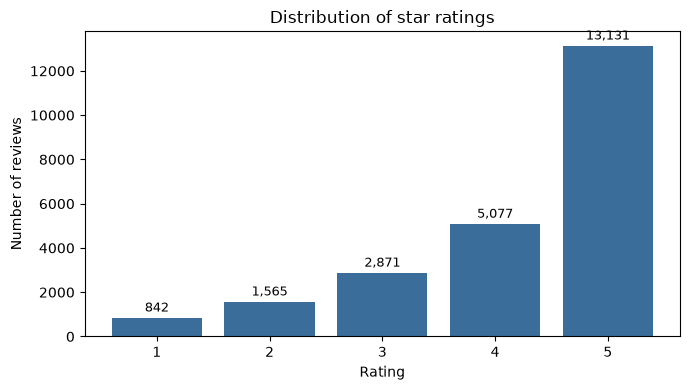

In [6]:
print(f"Minimum rating: {df['Rating'].min()}")
print(f"Maximum rating: {df['Rating'].max()}")
print()

rating_counts = df["Rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(2)
rating_table = pd.DataFrame({"count": rating_counts, "percent": rating_pct})
display(rating_table)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color="#3b6d9a")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of reviews")
ax.set_title("Distribution of star ratings")
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 150, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 6. Categories: `Class Name` and `Department Name`

Product taxonomy is mostly complete. There are **21 unique class names** (including 14 blank/missing rows) and **7 unique department names** (including the same 14 missing rows).

**Departments (review counts):**
- **Tops** — 10,468 (largest group)
- **Dresses** — 6,319
- **Bottoms** — 3,799
- **Intimate** — 1,735
- **Jackets** — 1,032
- **Trend** — 119
- *(missing)* — 14

**Classes** are more granular. The highest-volume classes are Dresses (6,319), Knits (4,843), Blouses (3,097), Sweaters (1,428), and Pants (1,388). Rare classes such as *Casual bottoms* (2) and *Chemises* (1) will be poor candidates for class-specific prompt evaluation.

When writing prompts, department is a better high-level grouping than class because several classes have very few examples.

Unique Class Name values: 21
Unique Department Name values: 7

=== Department Name — review counts ===


,review_count
Department Name,
Tops,10468
Dresses,6319
Bottoms,3799
Intimate,1735
Jackets,1032
Trend,119
(Missing),14


=== Class Name — review counts ===


,review_count
Class Name,
Dresses,6319
Knits,4843
Blouses,3097
Sweaters,1428
Pants,1388
Jeans,1147
Fine gauge,1100
Skirts,945
Jackets,704


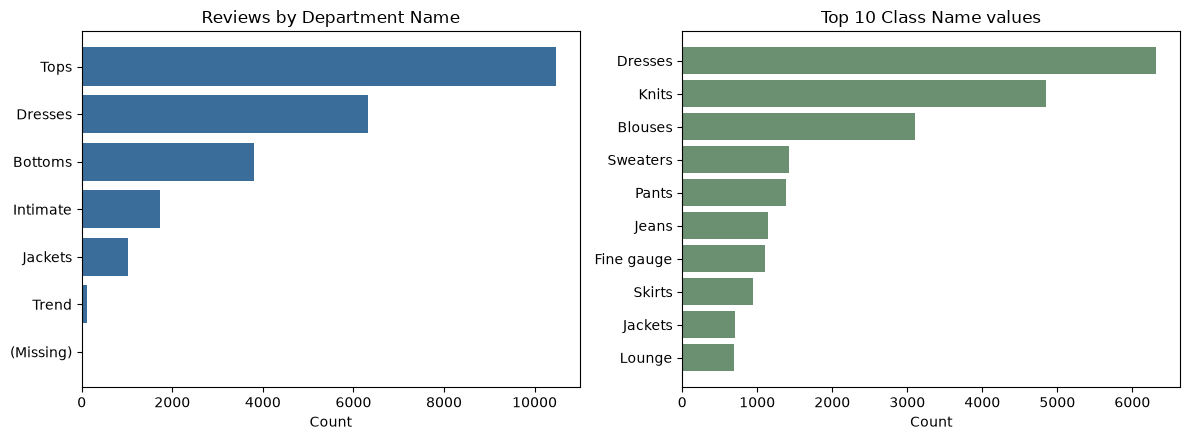

In [7]:
print("Unique Class Name values:", df["Class Name"].nunique(dropna=False))
print("Unique Department Name values:", df["Department Name"].nunique(dropna=False))
print()

print("=== Department Name — review counts ===")
dept_counts = (
    df["Department Name"]
    .fillna("(Missing)")
    .value_counts()
)
display(dept_counts.to_frame("review_count"))

print("=== Class Name — review counts ===")
class_counts = (
    df["Class Name"]
    .fillna("(Missing)")
    .value_counts()
)
display(class_counts.to_frame("review_count"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].barh(dept_counts.index[::-1], dept_counts.values[::-1], color="#3b6d9a")
axes[0].set_title("Reviews by Department Name")
axes[0].set_xlabel("Count")

top_class = class_counts.head(10)
axes[1].barh(top_class.index[::-1], top_class.values[::-1], color="#6b8f71")
axes[1].set_title("Top 10 Class Name values")
axes[1].set_xlabel("Count")
plt.tight_layout()
plt.show()

## 7. Diverse sample reviews (5-star, 3-star, 1-star)

Three rows are printed below from different rating bands and product classes. They illustrate why a single prompt must handle mixed language:

1. **5-star / recommended** — enthusiastic, specific, often mentions fit and compliments.
2. **3-star / mixed** — both praise and complaints (fit, quality, or design flaws) in the same paragraph.
3. **1-star / not recommended** — strong dissatisfaction; shorter or more pointed language.

These examples are a useful sanity check when we later ask a model to summarize sentiment or extract themes.

In [8]:
sample_cols = [
    "Clothing ID",
    "Rating",
    "Recommended IND",
    "Class Name",
    "Review Text",
]

# Prefer complete review text and different classes for diversity.
sample_specs = [
    {"rating": 5, "class_name": "Dresses"},
    {"rating": 3, "class_name": "Blouses"},
    {"rating": 1, "class_name": "Pants"},
]

samples = []
for spec in sample_specs:
    mask = (
        (df["Rating"] == spec["rating"])
        & (df["Class Name"] == spec["class_name"])
        & df["Review Text"].notna()
    )
    row = df.loc[mask, sample_cols].iloc[0]
    samples.append(row)

sample_df = pd.DataFrame(samples)
display(sample_df)

print("\n----- Full review text -----\n")
for _, row in sample_df.iterrows():
    rec = "Recommended" if row["Recommended IND"] == 1 else "Not recommended"
    print(f"Clothing ID {row['Clothing ID']} | {row['Rating']}-star | {rec} | {row['Class Name']}")
    print(row["Review Text"])
    print("-" * 80)

,Clothing ID,Rating,Recommended IND,Class Name,Review Text
1,1080,5,1,Dresses,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite. i bought a petite and am 5'8"". i love the length on me- hits just a little below the knee. would definitely be a true midi on someone who is truly petite."
144,829,3,0,Blouses,"My firned tried this on and her first comment was ""take it off, it is scratchy"", so i didn't bother trying it on. it is, however, beautiful, if you are not sensitive to scratchy material.\nfit was true to size."
646,1059,1,0,Pants,"I waited three months for these pants. when they finally arrived, i was mostly pleased. they seemed like the staple pant everyone is raving about. and they should have been.\r\nproblem one: they bag out. i got one wear out of them before i needed to wash and hang to dry (regained shape then).\r\nproblem two: the crotch split! in the front! i'm a teacher. i sincerely hope no one noticed! i read..."



----- Full review text -----

Clothing ID 1080 | 5-star | Recommended | Dresses
Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i bought a petite and am 5'8".  i love the length on me- hits just a little below the knee.  would definitely be a true midi on someone who is truly petite.
--------------------------------------------------------------------------------
Clothing ID 829 | 3-star | Not recommended | Blouses
My firned tried this on and her first comment was "take it off, it is scratchy", so i didn't bother trying it on. it is, however, beautiful, if you are not sensitive to scratchy material.
fit was true to size.
--------------------------------------------------------------------------------
Clothing ID 1059 | 1-star | Not recommended | Pants
I waited three months for these pants. when they finally arrived, i was mostly pleased. they seemed like the staple pant everyone is ravin

## 8. Takeaways for prompt engineering

1. **Primary text field:** Use `Review Text`. Drop the 845 empty reviews before calling a model.
2. **Optional context:** Include `Title`, `Class Name`, and `Department Name` when present; do not assume they exist.
3. **Labels already in the data:** `Rating` and `Recommended IND` can serve as weak supervision / evaluation targets for sentiment-style prompts, but they are correlated rather than identical.
4. **Class imbalance:** 5-star reviews dominate. Prompt tests and few-shot examples should include 1-star and 3-star reviews so the model sees mixed and negative language.
5. **Category coverage:** Tops, Dresses, and Bottoms cover most of the catalog. Niche classes (Trend, Chemises, Casual bottoms) should not drive prompt design.
6. **Normalize review text before prompt injection.** Some cells store Windows line breaks as literal `\r\n` characters (see row **646**: `\r\nproblem one: they bag out`). Collapse those into spaces so they do not leak into the model prompt:

```python
text = text.replace("\r\n", " ").strip()
```

Next step: use these findings to draft system and user prompts that summarize reviews and extract themes such as fit, quality, and style.